In [4]:
import pandas as pd
from optbinning import OptimalBinning

In [5]:
df = pd.read_csv("../data/output/df_credit_clear.csv")

In [8]:
df.columns

Index(['Unnamed: 0', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [13]:
from optbinning import OptimalBinning
import matplotlib.pyplot as plt

def optimal_and_plot(df, colonnes, target="loan_status"):
    results = {}

    for col in colonnes:
        print(f"\n==== {col} ====")

        x = df[col]
        y = df[target]

        # Binning
        optb = OptimalBinning(name=col, dtype="numerical", solver="cp")
        optb.fit(x, y)

        # Ajout des colonnes au df
        df[f"{col}_binned"] = optb.transform(x, metric="bins")
        df[f"{col}_woe"] = optb.transform(x, metric="woe")

        # Stocker
        results[col] = optb

        # Construire la table
        optb.binning_table.build()

        # Plot
        plt.figure(figsize=(8, 4))
        optb.binning_table.plot(metric="woe")
        plt.title(f"WOE Plot - {col}")
        plt.show()

    return results



==== Unnamed: 0 ====


<Figure size 800x400 with 0 Axes>

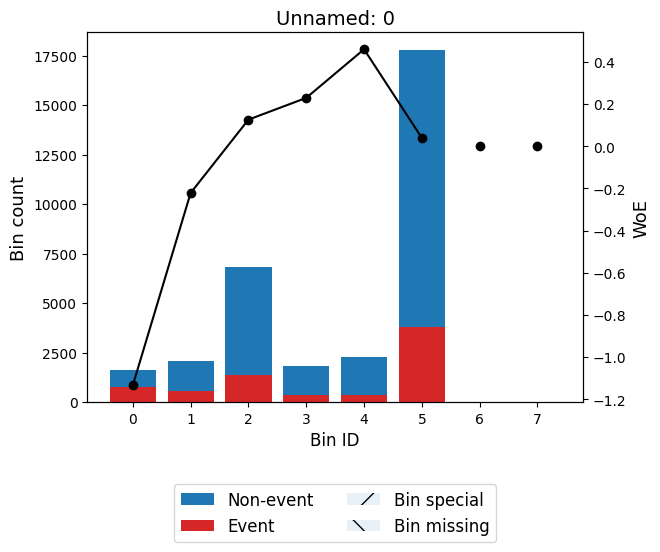

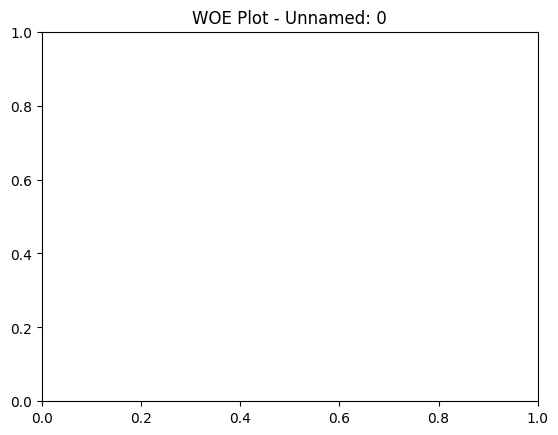


==== person_age ====


<Figure size 800x400 with 0 Axes>

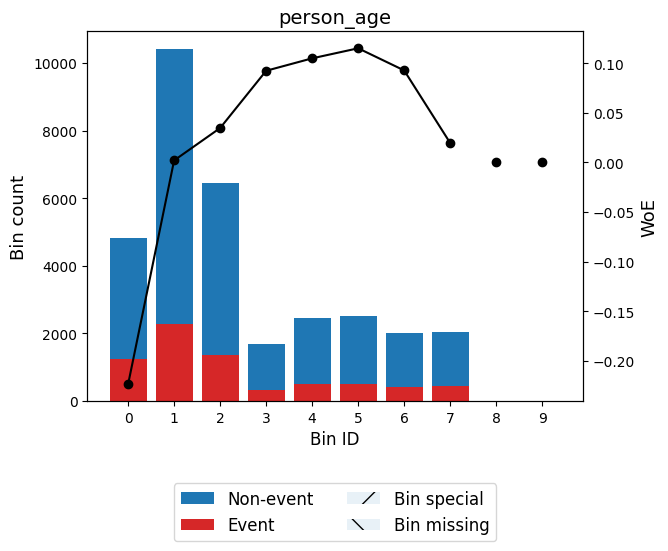

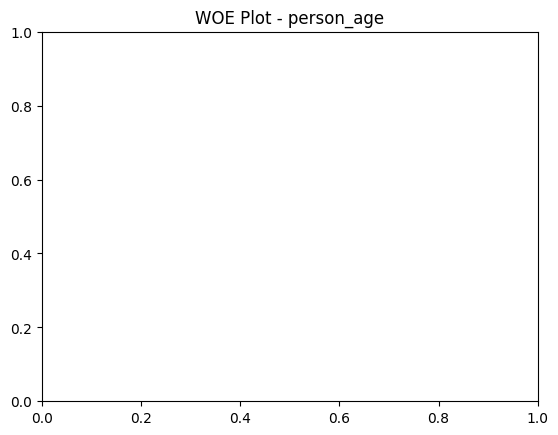


==== person_income ====


<Figure size 800x400 with 0 Axes>

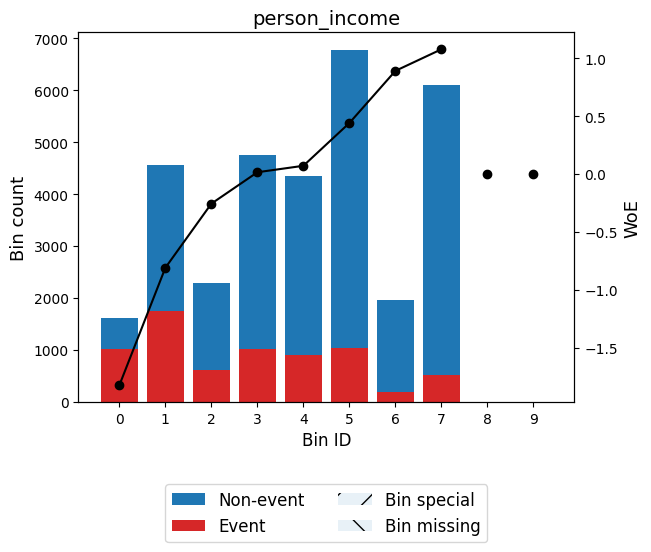

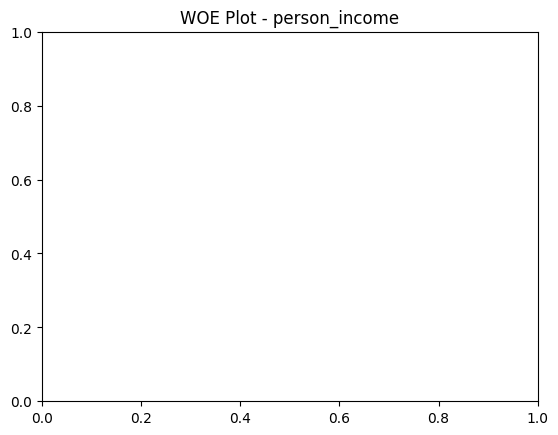


==== person_emp_length ====


<Figure size 800x400 with 0 Axes>

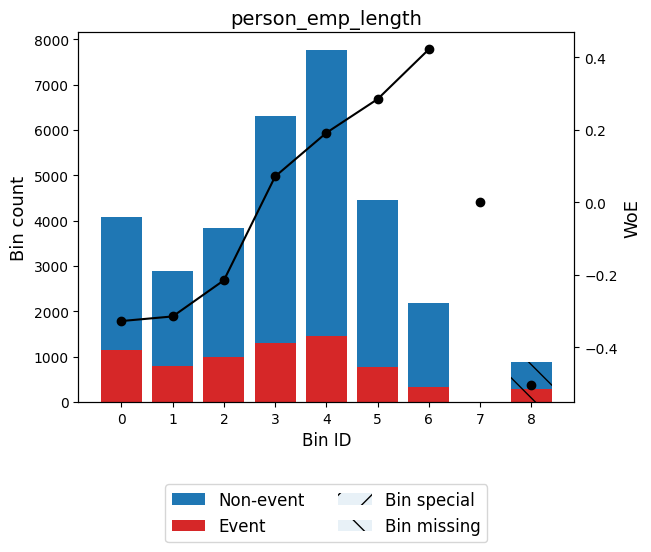

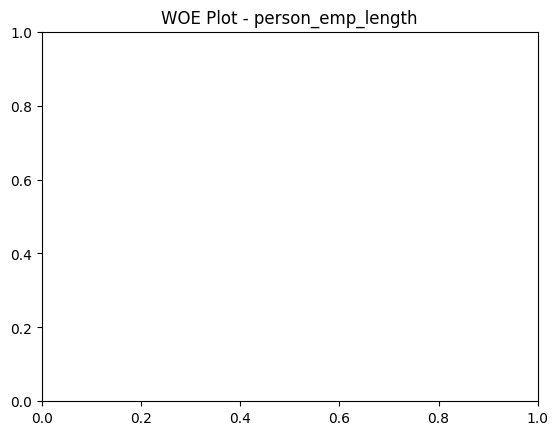


==== loan_amnt ====


<Figure size 800x400 with 0 Axes>

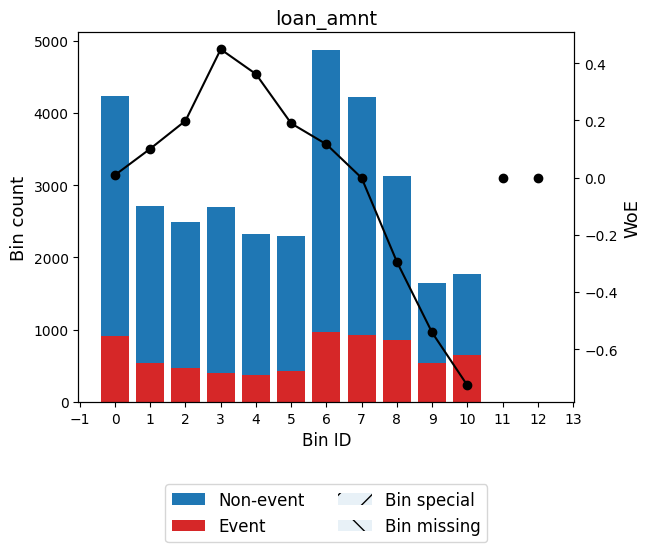

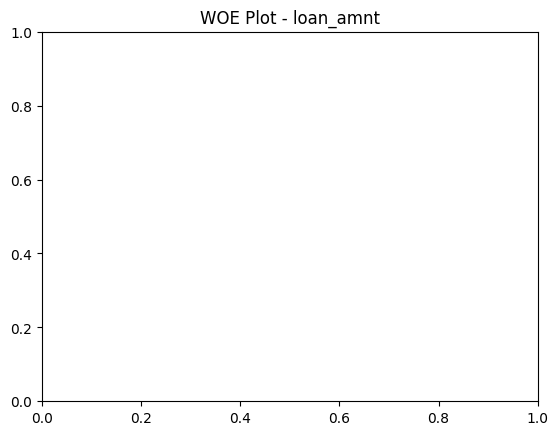


==== loan_int_rate ====


<Figure size 800x400 with 0 Axes>

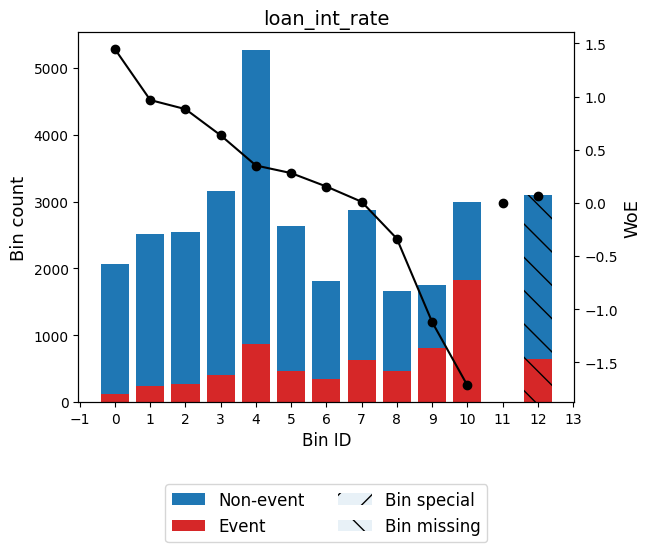

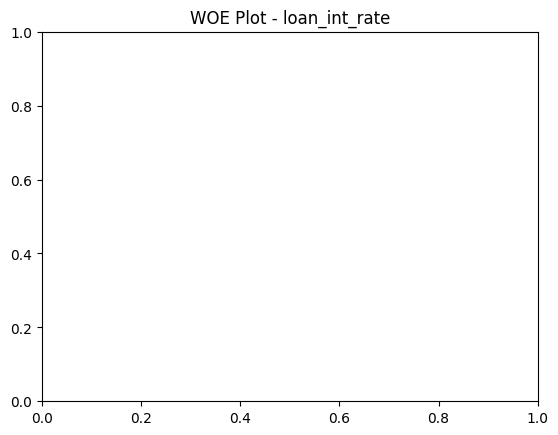


==== loan_status ====


<Figure size 800x400 with 0 Axes>

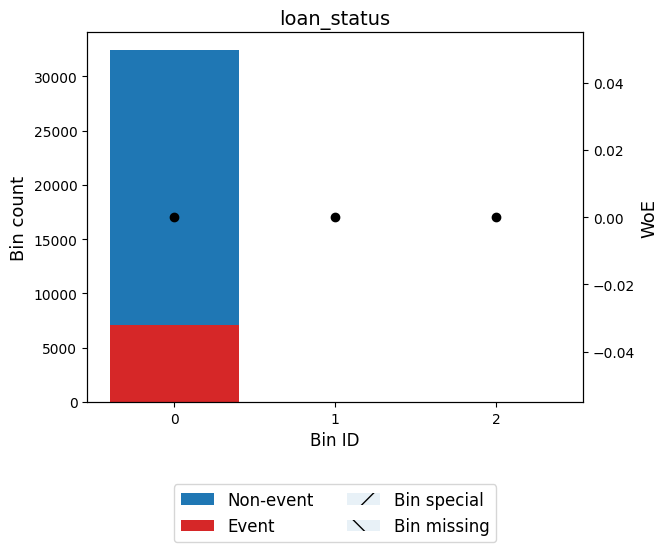

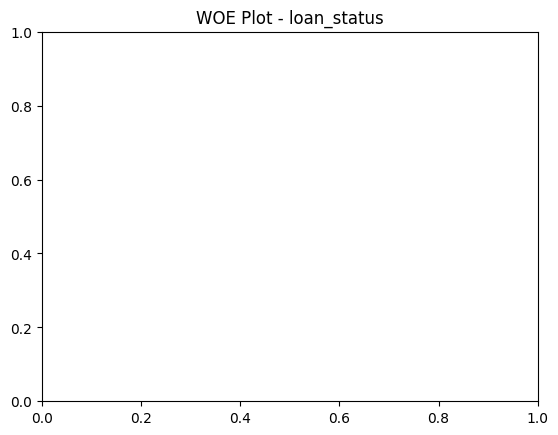


==== loan_percent_income ====


<Figure size 800x400 with 0 Axes>

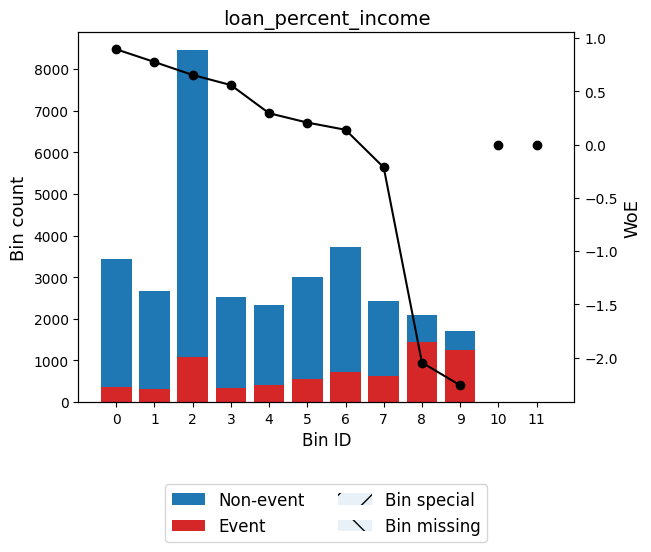

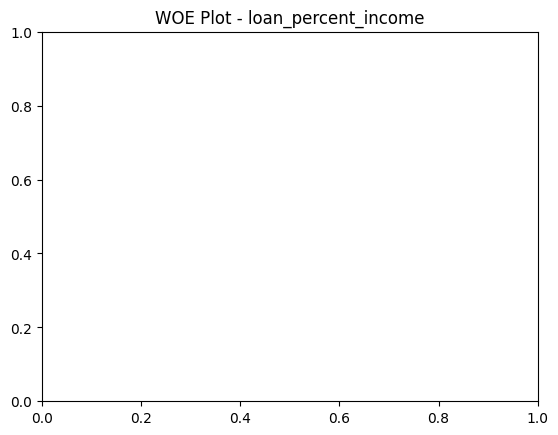


==== cb_person_cred_hist_length ====


<Figure size 800x400 with 0 Axes>

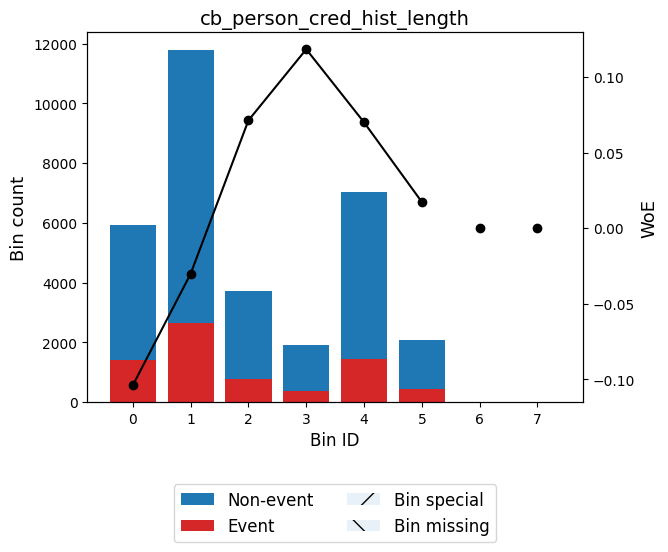

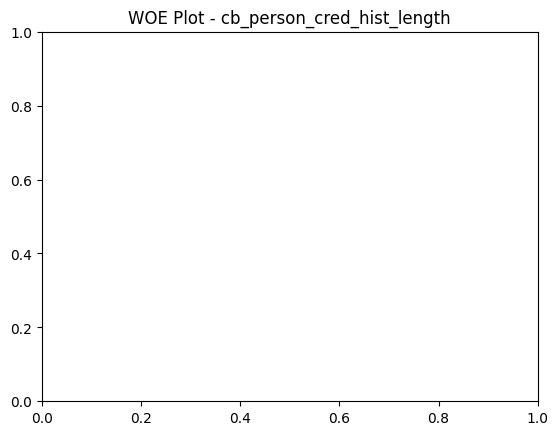


==== Unnamed: 0_woe ====


<Figure size 800x400 with 0 Axes>

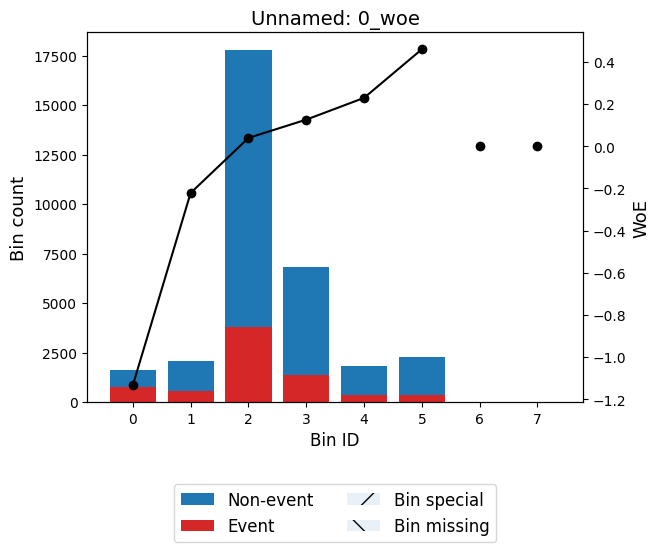

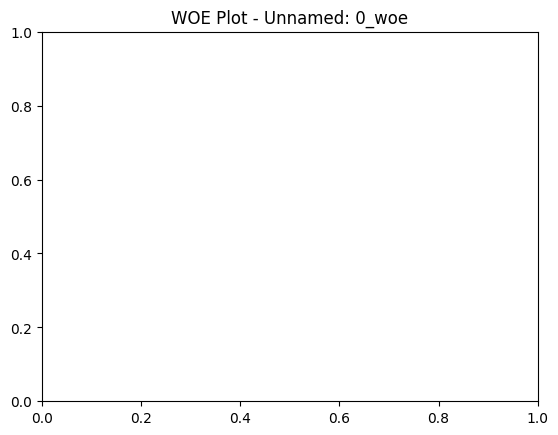


==== person_age_woe ====


<Figure size 800x400 with 0 Axes>

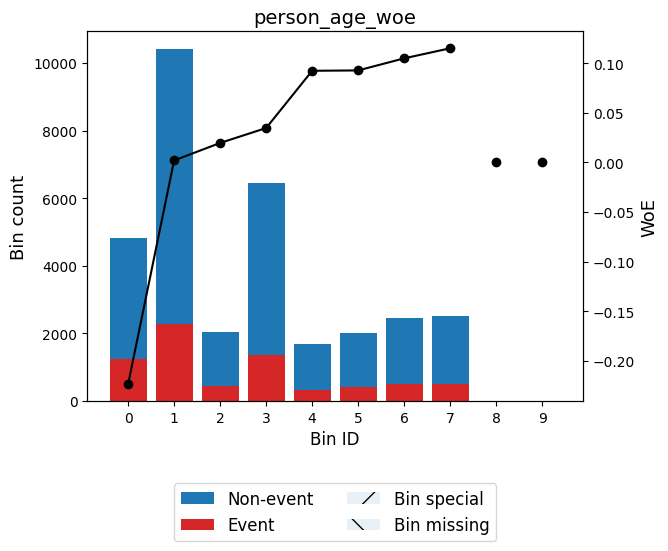

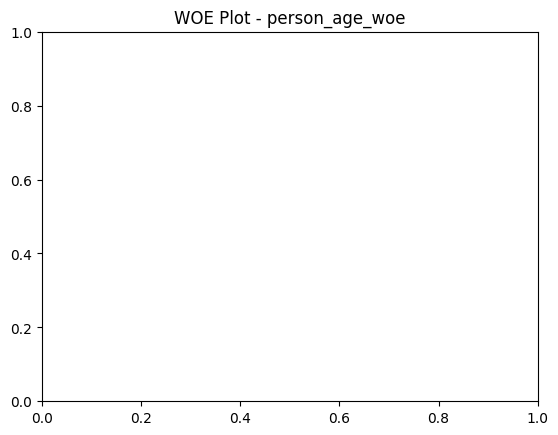


==== person_income_woe ====


<Figure size 800x400 with 0 Axes>

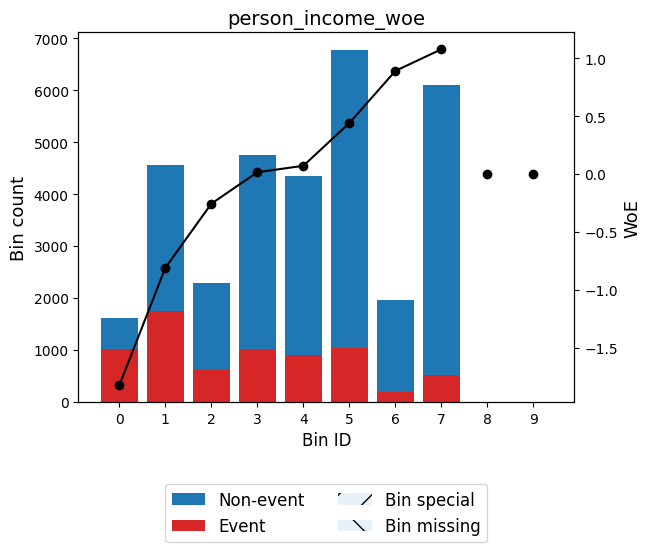

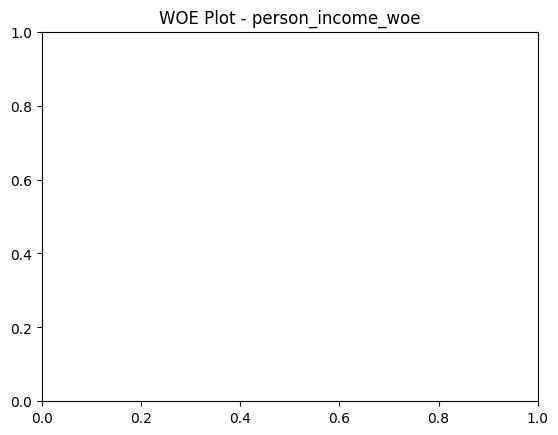


==== person_emp_length_woe ====


<Figure size 800x400 with 0 Axes>

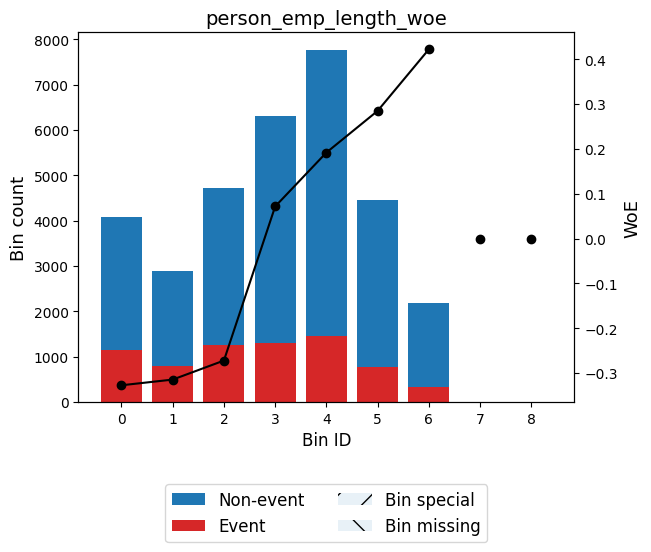

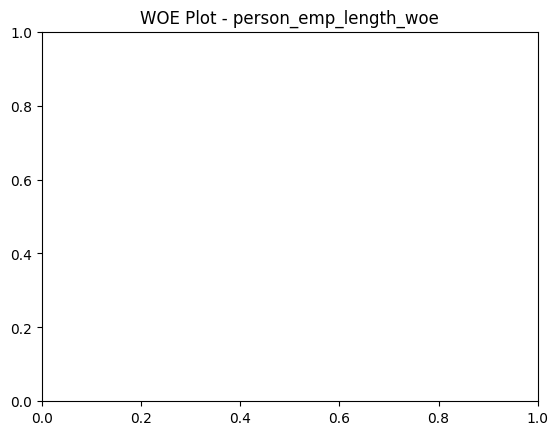


==== loan_amnt_woe ====


<Figure size 800x400 with 0 Axes>

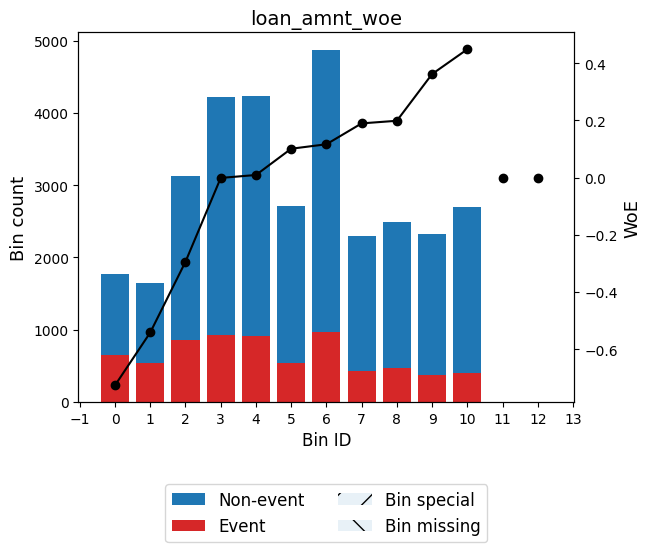

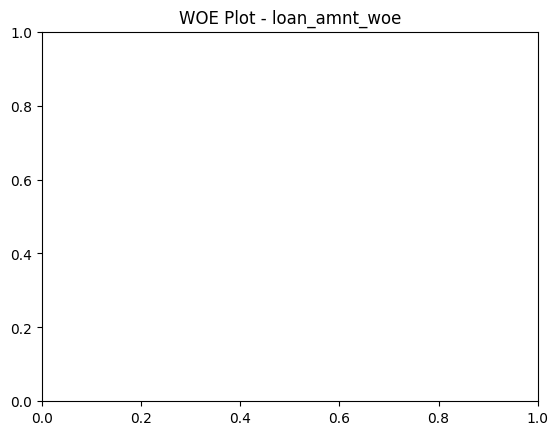


==== loan_int_rate_woe ====


<Figure size 800x400 with 0 Axes>

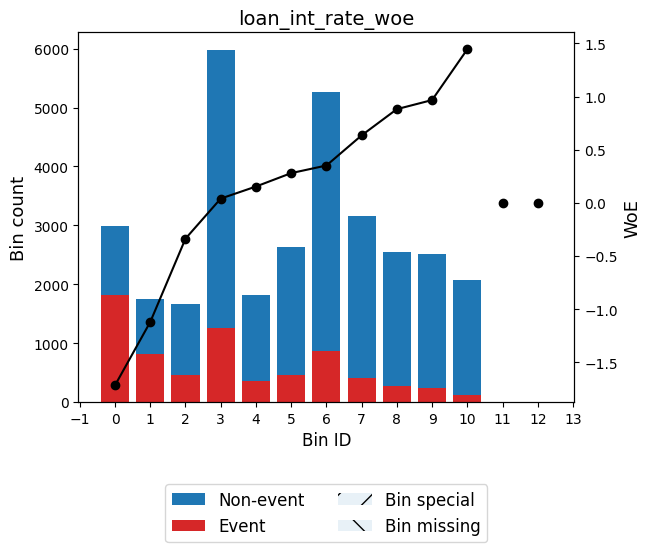

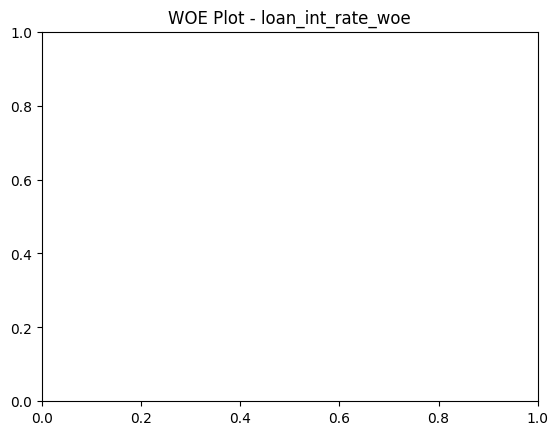


==== loan_status_woe ====


<Figure size 800x400 with 0 Axes>

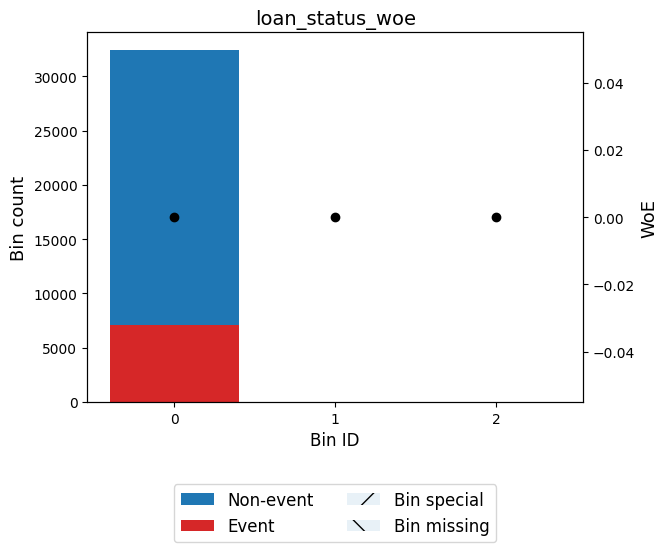

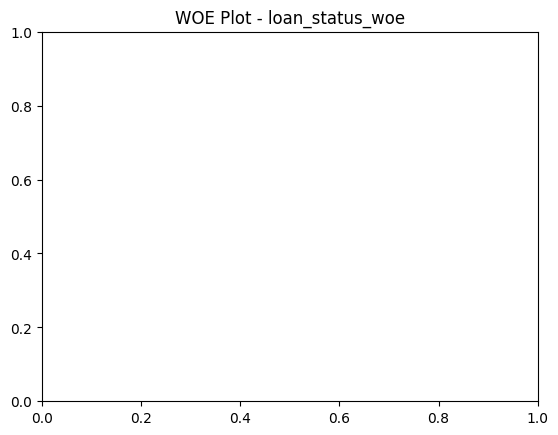


==== loan_percent_income_woe ====


<Figure size 800x400 with 0 Axes>

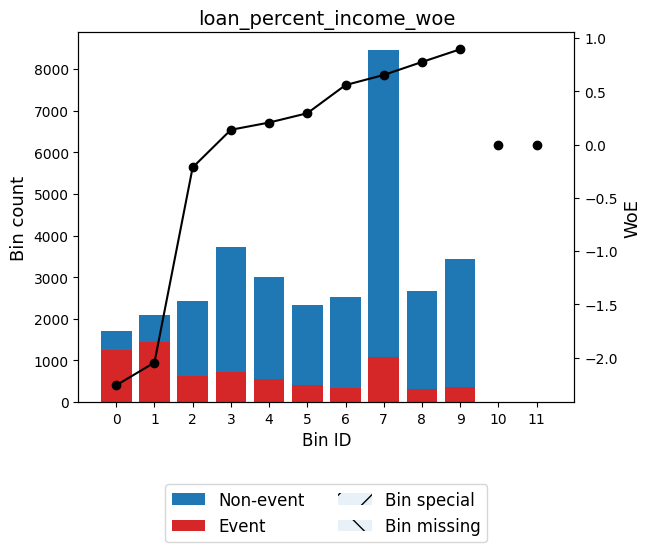

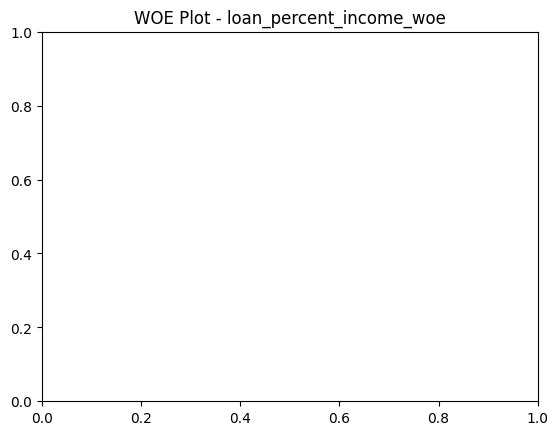


==== cb_person_cred_hist_length_woe ====


<Figure size 800x400 with 0 Axes>

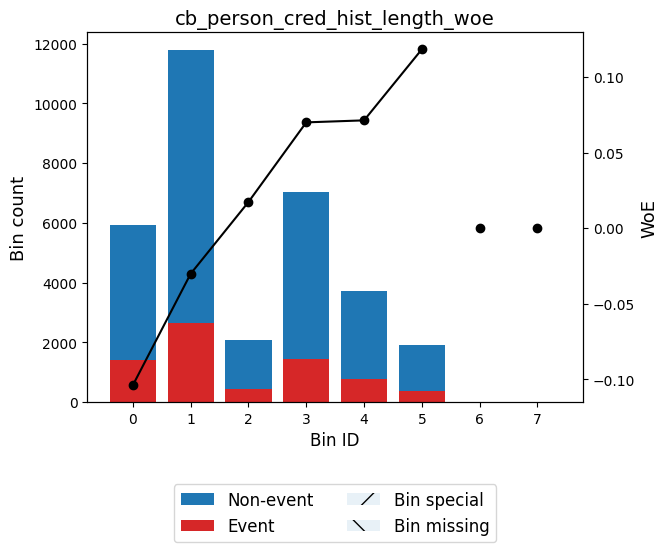

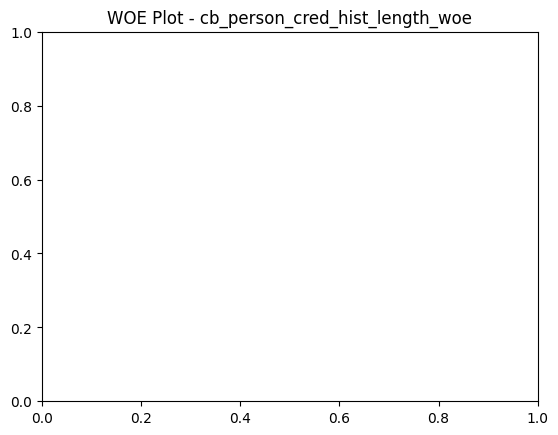

In [16]:
colonnes_num = df.select_dtypes(include=["float64", "int64"]).columns

resultats = optimal_and_plot(df, colonnes_num)


In [18]:
from optbinning import OptimalBinning

def optimal_loop(df, variables, target='loan_status'):
    for variable in variables:
        print(f"\n========================")
        print(f" Binning de : {variable}")
        print(f"========================")

        optb = OptimalBinning(
            name=variable,
            dtype="numerical",
            solver="cp",
            min_n_bins=4,
            max_n_bins=5
        )

        # Fit
        optb.fit(df[variable], df[target])

        # Table
        bin_table = optb.binning_table.build()
        print(bin_table)

        # Plot
        optb.binning_table.plot(metric="event_rate")



 Binning de : Unnamed: 0
                         Bin  Count  Count (%)  Non-event  Event  Event rate  \
0            (-inf, 1626.50)   1621   0.050017        867    754    0.465145   
1         [1626.50, 3708.50)   2082   0.064241       1543    539    0.258886   
2        [3708.50, 12370.50)   8662   0.267271       6977   1685    0.194528   
3       [12370.50, 14634.50)   2264   0.069857       1924    340    0.150177   
4            [14634.50, inf)  17780   0.548613      14010   3770    0.212036   
5                    Special      0   0.000000          0      0    0.000000   
6                    Missing      0   0.000000          0      0    0.000000   
Totals                        32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -1.133584  0.081773  0.009707  
1      -0.221463  0.003346  0.000417  
2       0.147623  0.005583  0.000697  
3       0.459985  0.012887  0.001597  
4       0.039465  0.000845  0.000106  
5            0.0  0

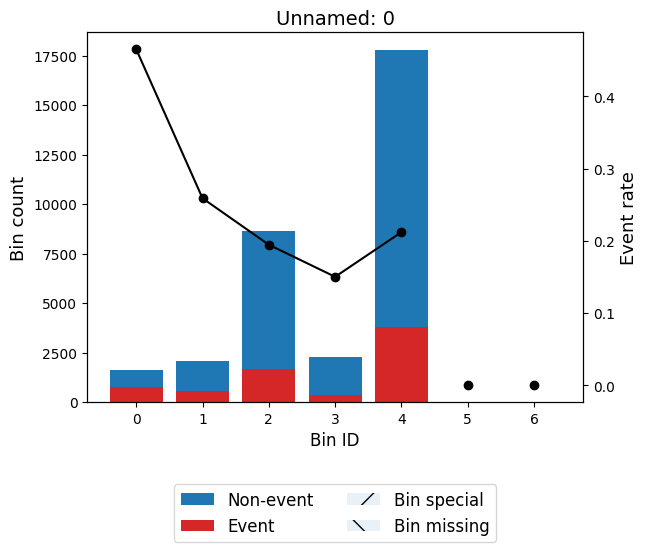


 Binning de : person_age
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, 22.50)   4833   0.149125       3580   1253    0.259259   
1       [22.50, 25.50)  10410   0.321207       8137   2273    0.218348   
2       [25.50, 28.50)   6437   0.198618       5067   1370    0.212832   
3       [28.50, 38.50)   8672   0.267580       6923   1749    0.201684   
4         [38.50, inf)   2057   0.063470       1614    443    0.215362   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV            JS  
0      -0.223409  0.007907  9.863387e-04  
1        0.00209  0.000001  1.753033e-07  
2       0.034707  0.000237  2.961320e-05  
3       0.102574  0.002734  3.416060e-04  
4        0.01967  0.000024  3.052664e-06  
5            0.0  0.000000  0.000000e+00  
6     

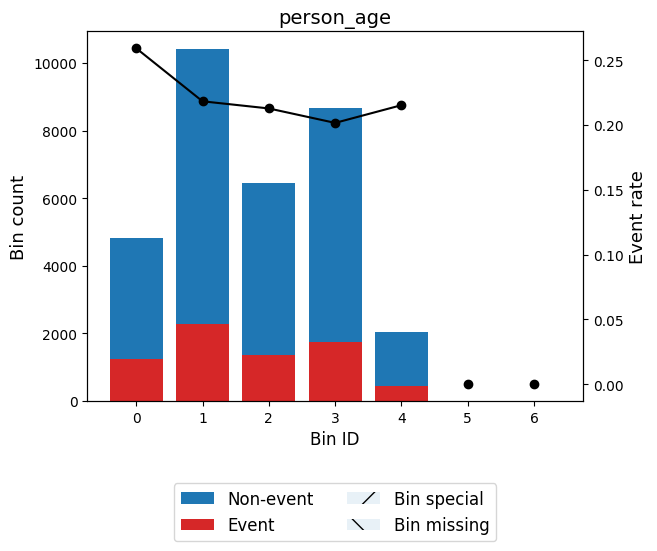


 Binning de : person_income
                         Bin  Count  Count (%)  Non-event  Event  Event rate  \
0           (-inf, 22920.00)   1621   0.050017        593   1028    0.634176   
1       [22920.00, 34999.50)   4563   0.140794       2802   1761    0.385930   
2       [34999.50, 59982.00)  11397   0.351662       8863   2534    0.222339   
3       [59982.00, 79993.50)   6772   0.208954       5739   1033    0.152540   
4            [79993.50, inf)   8056   0.248573       7324    732    0.090864   
5                    Special      0   0.000000          0      0    0.000000   
6                    Missing      0   0.000000          0      0    0.000000   
Totals                        32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -1.823407  0.221753  0.024422  
1      -0.808779  0.111441  0.013562  
2      -0.021145  0.000158  0.000020  
3       0.441587  0.035729  0.004430  
4       1.029901  0.191534  0.022937  
5            0.0

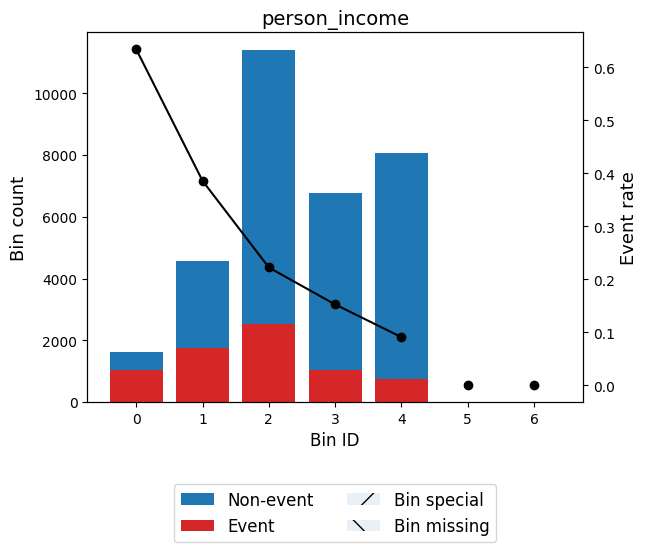


 Binning de : person_emp_length
                  Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, 1.50)   6983   0.215465       5037   1946    0.278677   
1        [1.50, 2.50)   3831   0.118208       2844    987    0.257635   
2        [2.50, 4.50)   6303   0.194483       5000   1303    0.206727   
3       [4.50, 11.50)  12225   0.377210       9992   2233    0.182658   
4        [11.50, inf)   2180   0.067265       1842    338    0.155046   
5             Special      0   0.000000          0      0    0.000000   
6             Missing    887   0.027369        606    281    0.316798   
Totals                 32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -0.322196  0.024365  0.003033  
1      -0.214934  0.005789  0.000722  
2       0.071538  0.000975  0.000122  
3       0.225208  0.017921  0.002235  
4        0.42233  0.010583  0.001313  
5            0.0  0.000000  0.000000  
6      -0.504706  0.007930  0.000981

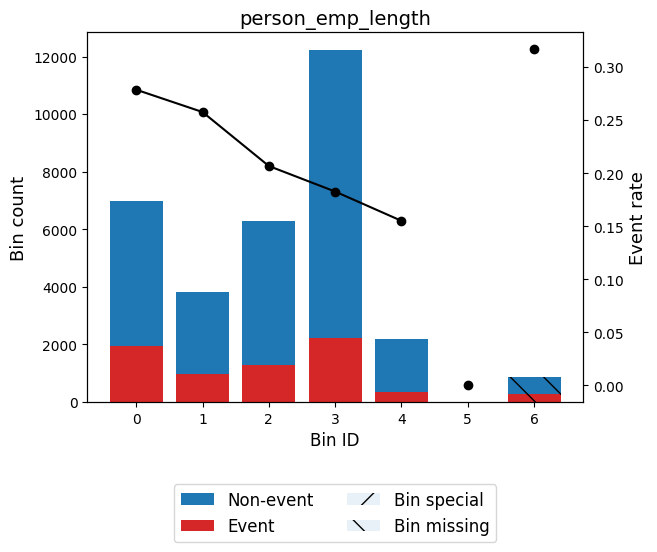


 Binning de : loan_amnt
                         Bin  Count  Count (%)  Non-event  Event  Event rate  \
0            (-inf, 5062.50)   9443   0.291370       7510   1933    0.204702   
1         [5062.50, 7387.50)   5022   0.154957       4234    788    0.156910   
2        [7387.50, 14487.50)  11398   0.351692       9069   2329    0.204334   
3       [14487.50, 18087.50)   3131   0.096609       2276    855    0.273076   
4            [18087.50, inf)   3415   0.105372       2232   1183    0.346413   
5                    Special      0   0.000000          0      0    0.000000   
6                    Missing      0   0.000000          0      0    0.000000   
Totals                        32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0       0.083931  0.002004  0.000250  
1       0.408173  0.022874  0.002840  
2       0.086192  0.002549  0.000319  
3      -0.294158  0.009043  0.001126  
4      -0.638386  0.050275  0.006180  
5            0.0  0.

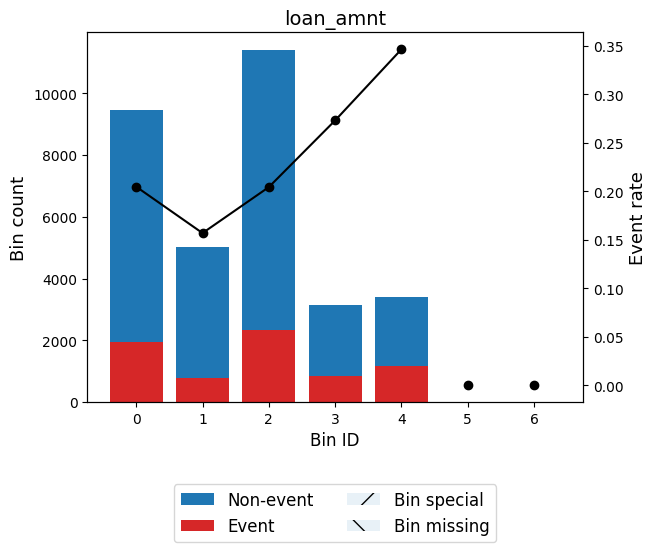


 Binning de : loan_int_rate
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0         (-inf, 7.89)   7137   0.220217       6502    635    0.088973   
1        [7.89, 12.72)  12891   0.397760      10803   2088    0.161973   
2       [12.72, 14.37)   4541   0.140115       3449   1092    0.240476   
3       [14.37, 15.28)   1750   0.053997        942    808    0.461714   
4         [15.28, inf)   2996   0.092443       1172   1824    0.608812   
5              Special      0   0.000000          0      0    0.000000   
6              Missing   3094   0.095467       2453    641    0.207175   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0       1.053009  0.176058  0.021044  
1       0.370386  0.048913  0.006079  
2      -0.123157  0.002199  0.000275  
3      -1.119788  0.085992  0.010220  
4      -1.715551  0.362068  0.040415  
5            0.0  0.000000  0.000000  
6       0.068807  0.000443  0.0

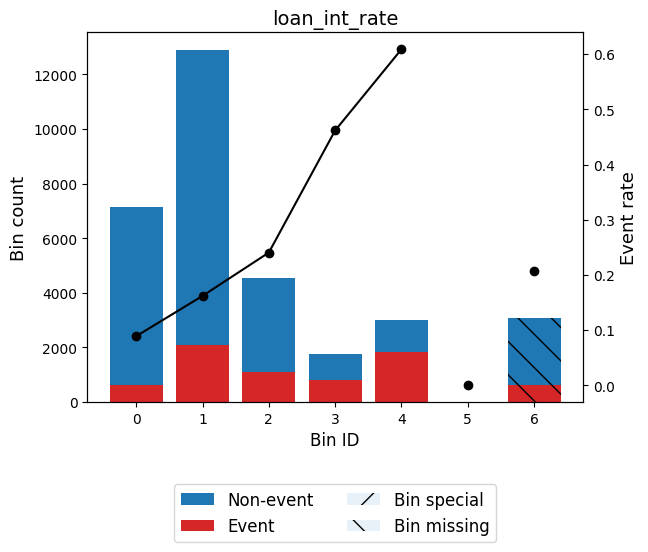


 Binning de : loan_status
                Bin  Count  Count (%)  Non-event  Event  Event rate  WoE   IV  \
0       (-inf, inf)  32409        1.0      25321   7088    0.218705  0.0  0.0   
1           Special      0        0.0          0      0    0.000000  0.0  0.0   
2           Missing      0        0.0          0      0    0.000000  0.0  0.0   
Totals               32409        1.0      25321   7088    0.218705       0.0   

         JS  
0       0.0  
1       0.0  
2       0.0  
Totals  0.0  


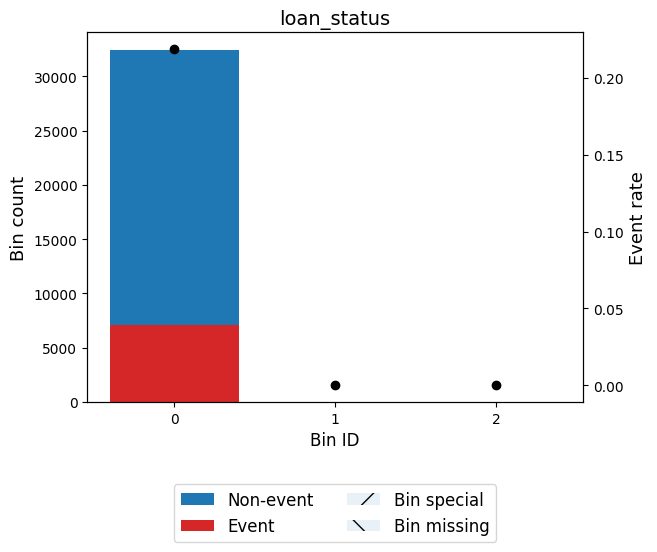


 Binning de : loan_percent_income
                 Bin  Count  Count (%)  Non-event  Event  Event rate  \
0       (-inf, 0.07)   6100   0.188219       5443    657    0.107705   
1       [0.07, 0.16)  10986   0.338980       9562   1424    0.129620   
2       [0.16, 0.25)   9075   0.280015       7383   1692    0.186446   
3       [0.25, 0.31)   2430   0.074979       1804    626    0.257613   
4        [0.31, inf)   3818   0.117807       1129   2689    0.704295   
5            Special      0   0.000000          0      0    0.000000   
6            Missing      0   0.000000          0      0    0.000000   
Totals                32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0       0.841171  0.102848  0.012490  
1       0.631096  0.111533  0.013715  
2       0.200038  0.010575  0.001320  
3       -0.21482  0.003668  0.000458  
4      -2.141068  0.716800  0.075646  
5            0.0  0.000000  0.000000  
6            0.0  0.000000  0.000000  
Tota

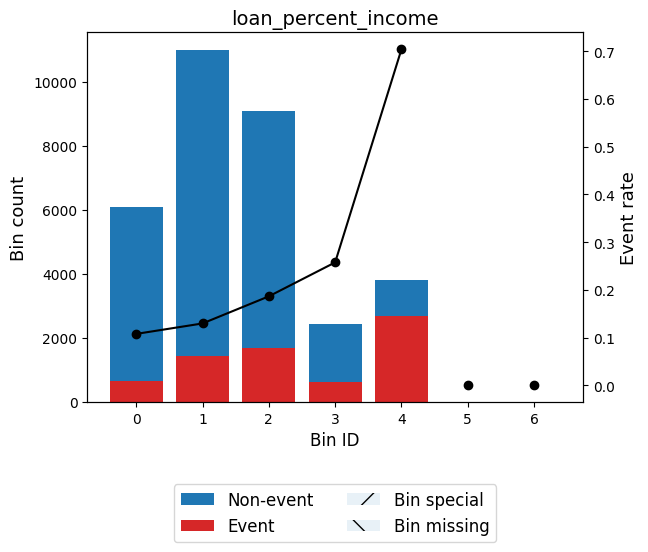


 Binning de : cb_person_cred_hist_length
                  Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, 2.50)   5924   0.182789       4520   1404    0.237002   
1        [2.50, 4.50)  11781   0.363510       9143   2638    0.223920   
2        [4.50, 9.50)   9403   0.290135       7457   1946    0.206955   
3       [9.50, 13.50)   3234   0.099787       2580    654    0.202226   
4        [13.50, inf)   2067   0.063779       1621    446    0.215772   
5             Special      0   0.000000          0      0    0.000000   
6             Missing      0   0.000000          0      0    0.000000   
Totals                 32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -0.104044  0.002036  0.000254  
1      -0.030263  0.000336  0.000042  
2       0.070146  0.001399  0.000175  
3       0.099206  0.000955  0.000119  
4       0.017249  0.000019  0.000002  
5            0.0  0.000000  0.000000  
6            0.0  0.000000 

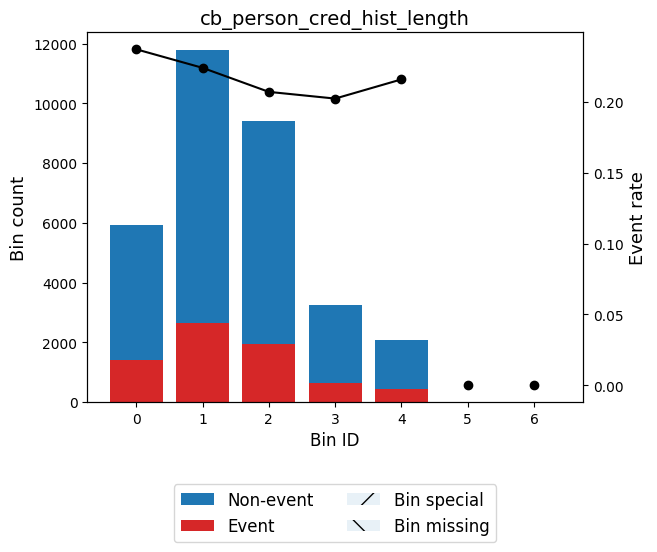


 Binning de : Unnamed: 0_woe
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -0.68)   1621   0.050017        867    754    0.465145   
1       [-0.68, -0.09)   2082   0.064241       1543    539    0.258886   
2        [-0.09, 0.08)  17780   0.548613      14010   3770    0.212036   
3         [0.08, 0.34)   8662   0.267271       6977   1685    0.194528   
4          [0.34, inf)   2264   0.069857       1924    340    0.150177   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -1.133584  0.081773  0.009707  
1      -0.221463  0.003346  0.000417  
2       0.039465  0.000845  0.000106  
3       0.147623  0.005583  0.000697  
4       0.459985  0.012887  0.001597  
5            0.0  0.000000  0.000000  
6            0.0  0.000000  0.

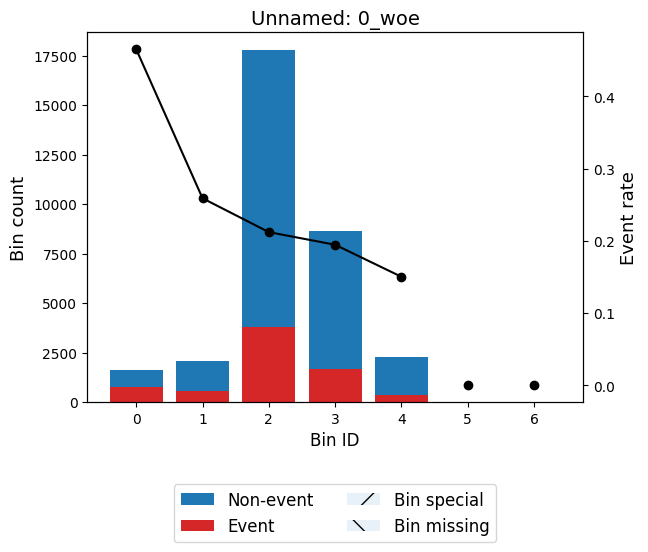


 Binning de : person_age_woe
                  Bin  Count  Count (%)  Non-event  Event  Event rate  \
0       (-inf, -0.11)   4833   0.149125       3580   1253    0.259259   
1       [-0.11, 0.01)  10410   0.321207       8137   2273    0.218348   
2        [0.01, 0.06)   8494   0.262088       6681   1813    0.213445   
3        [0.06, 0.10)   3699   0.114135       2947    752    0.203298   
4         [0.10, inf)   4973   0.153445       3976    997    0.200483   
5             Special      0   0.000000          0      0    0.000000   
6             Missing      0   0.000000          0      0    0.000000   
Totals                 32409   1.000000      25321   7088    0.218705   

             WoE        IV            JS  
0      -0.223409  0.007907  9.863387e-04  
1        0.00209  0.000001  1.753033e-07  
2       0.031054  0.000251  3.131546e-05  
3       0.092576  0.000953  1.190424e-04  
4        0.11005  0.001801  2.249873e-04  
5            0.0  0.000000  0.000000e+00  
6          

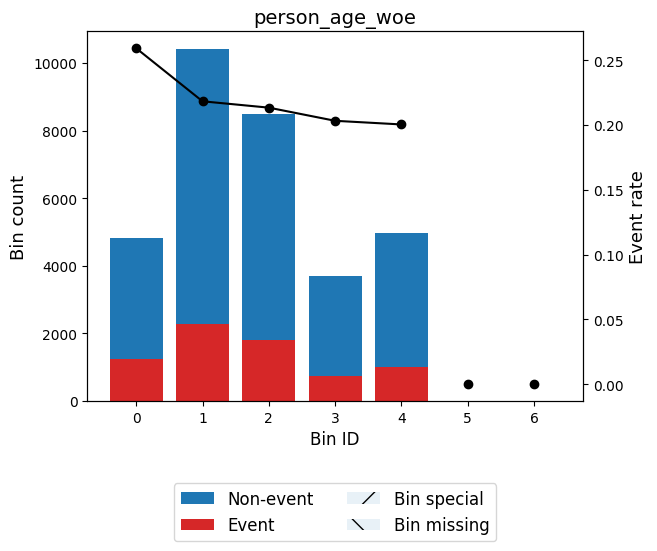


 Binning de : person_income_woe
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -1.32)   1621   0.050017        593   1028    0.634176   
1       [-1.32, -0.53)   4563   0.140794       2802   1761    0.385930   
2        [-0.53, 0.26)  11397   0.351662       8863   2534    0.222339   
3         [0.26, 0.67)   6772   0.208954       5739   1033    0.152540   
4          [0.67, inf)   8056   0.248573       7324    732    0.090864   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -1.823407  0.221753  0.024422  
1      -0.808779  0.111441  0.013562  
2      -0.021145  0.000158  0.000020  
3       0.441587  0.035729  0.004430  
4       1.029901  0.191534  0.022937  
5            0.0  0.000000  0.000000  
6            0.0  0.000000 

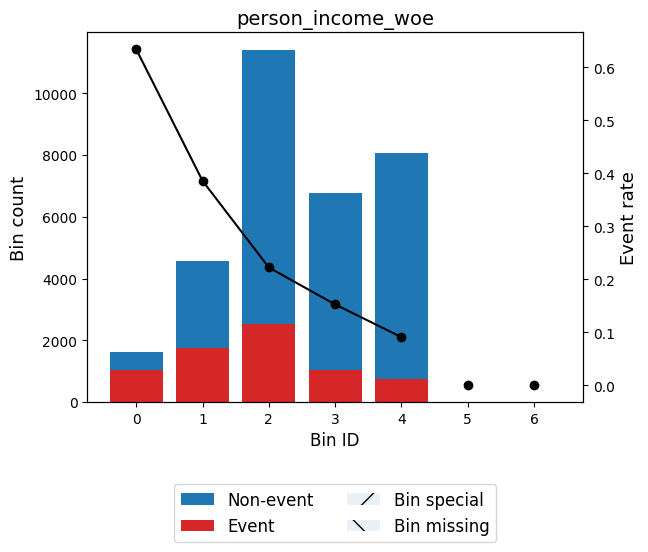


 Binning de : person_emp_length_woe
                 Bin  Count  Count (%)  Non-event  Event  Event rate  \
0       (-inf, 0.04)  11701   0.361042       8487   3214    0.274677   
1       [0.04, 0.13)   6303   0.194483       5000   1303    0.206727   
2       [0.13, 0.24)   7763   0.239532       6306   1457    0.187685   
3       [0.24, 0.35)   4462   0.137678       3686    776    0.173913   
4        [0.35, inf)   2180   0.067265       1842    338    0.155046   
5            Special      0   0.000000          0      0    0.000000   
6            Missing      0   0.000000          0      0    0.000000   
Totals                32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -0.302212  0.035741  0.004451  
1       0.071538  0.000975  0.000122  
2       0.191891  0.008344  0.001041  
3       0.284914  0.010283  0.001281  
4        0.42233  0.010583  0.001313  
5            0.0  0.000000  0.000000  
6            0.0  0.000000  0.000000  
To

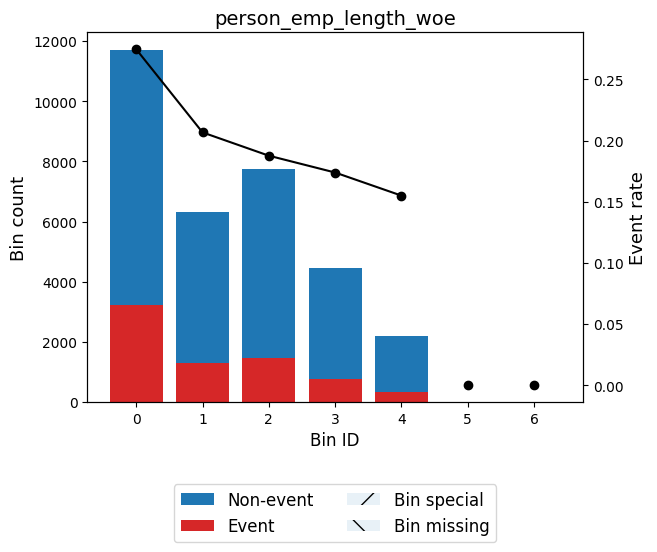


 Binning de : loan_amnt_woe
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -0.42)   3415   0.105372       2232   1183    0.346413   
1       [-0.42, -0.15)   3131   0.096609       2276    855    0.273076   
2        [-0.15, 0.06)   8463   0.261131       6618   1845    0.218008   
3         [0.06, 0.28)  12378   0.381931       9961   2417    0.195266   
4          [0.28, inf)   5022   0.154957       4234    788    0.156910   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV            JS  
0      -0.638386  0.050275  6.179820e-03  
1      -0.294158  0.009043  1.126263e-03  
2       0.004083  0.000004  5.435501e-07  
3       0.142919  0.007488  9.351485e-04  
4       0.408173  0.022874  2.839528e-03  
5            0.0  0.000000  0.000000e+00  
6  

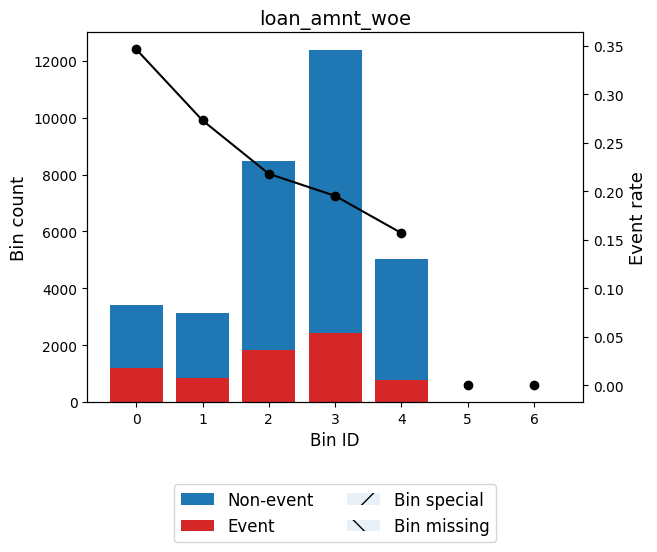


 Binning de : loan_int_rate_woe
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -1.42)   2996   0.092443       1172   1824    0.608812   
1       [-1.42, -0.73)   1750   0.053997        942    808    0.461714   
2        [-0.73, 0.22)   9454   0.291709       7369   2085    0.220542   
3         [0.22, 0.76)  11072   0.341633       9336   1736    0.156792   
4          [0.76, inf)   7137   0.220217       6502    635    0.088973   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -1.715551  0.362068  0.040415  
1      -1.119788  0.085992  0.010220  
2      -0.010718  0.000034  0.000004  
3       0.409063  0.050636  0.006286  
4       1.053009  0.176058  0.021044  
5            0.0  0.000000  0.000000  
6            0.0  0.000000 

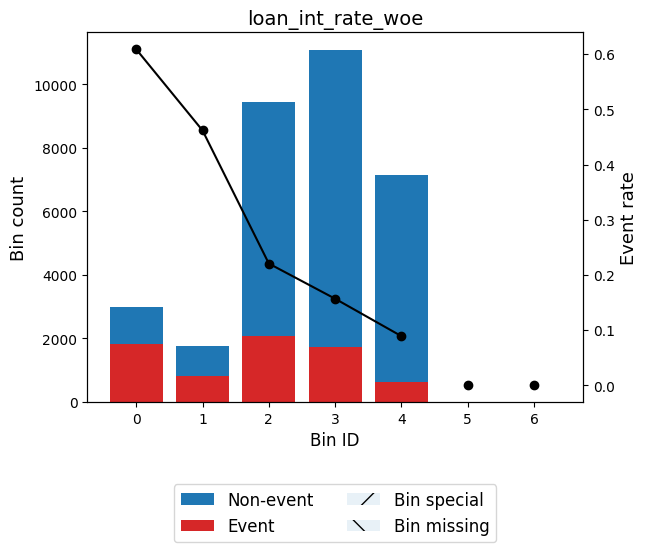


 Binning de : loan_status_woe
                Bin  Count  Count (%)  Non-event  Event  Event rate  WoE   IV  \
0       (-inf, inf)  32409        1.0      25321   7088    0.218705  0.0  0.0   
1           Special      0        0.0          0      0    0.000000  0.0  0.0   
2           Missing      0        0.0          0      0    0.000000  0.0  0.0   
Totals               32409        1.0      25321   7088    0.218705       0.0   

         JS  
0       0.0  
1       0.0  
2       0.0  
Totals  0.0  


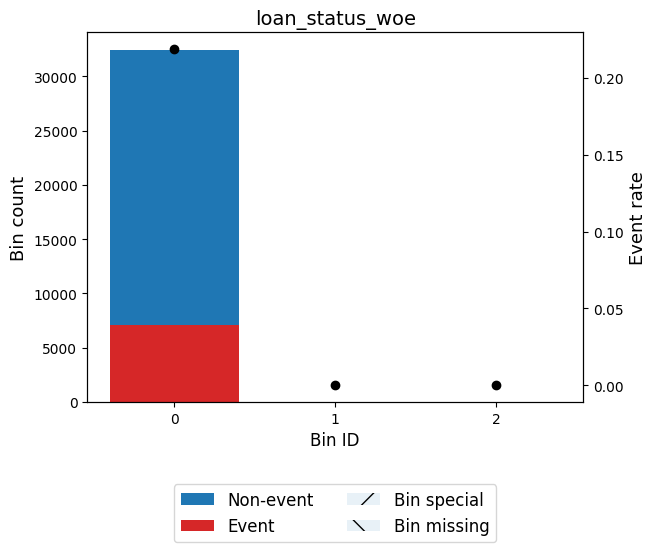


 Binning de : loan_percent_income_woe
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -1.13)   3818   0.117807       1129   2689    0.704295   
1       [-1.13, -0.04)   2430   0.074979       1804    626    0.257613   
2        [-0.04, 0.43)   9075   0.280015       7383   1692    0.186446   
3         [0.43, 0.71)  10986   0.338980       9562   1424    0.129620   
4          [0.71, inf)   6100   0.188219       5443    657    0.107705   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -2.141068  0.716800  0.075646  
1       -0.21482  0.003668  0.000458  
2       0.200038  0.010575  0.001320  
3       0.631096  0.111533  0.013715  
4       0.841171  0.102848  0.012490  
5            0.0  0.000000  0.000000  
6            0.0  0.0

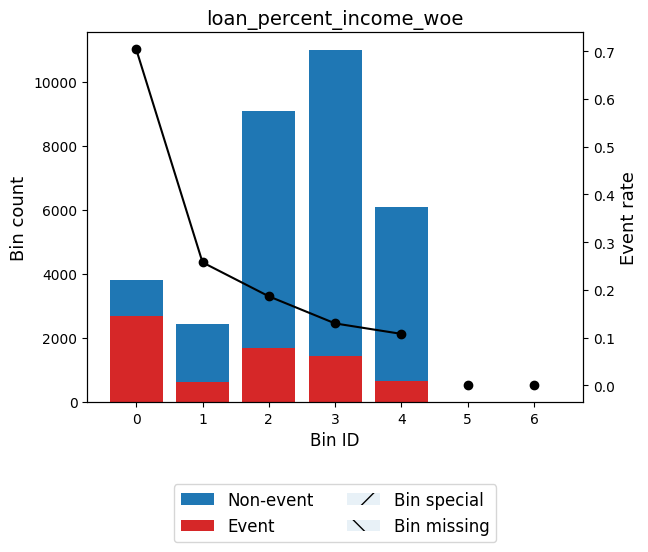


 Binning de : cb_person_cred_hist_length_woe
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -0.07)   5924   0.182789       4520   1404    0.237002   
1       [-0.07, -0.01)  11781   0.363510       9143   2638    0.223920   
2        [-0.01, 0.04)   2067   0.063779       1621    446    0.215772   
3         [0.04, 0.09)  10739   0.331359       8517   2222    0.206909   
4          [0.09, inf)   1898   0.058564       1520    378    0.199157   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -0.104044  0.002036  0.000254  
1      -0.030263  0.000336  0.000042  
2       0.017249  0.000019  0.000002  
3       0.070426  0.001611  0.000201  
4       0.118341  0.000793  0.000099  
5            0.0  0.000000  0.000000  
6            0

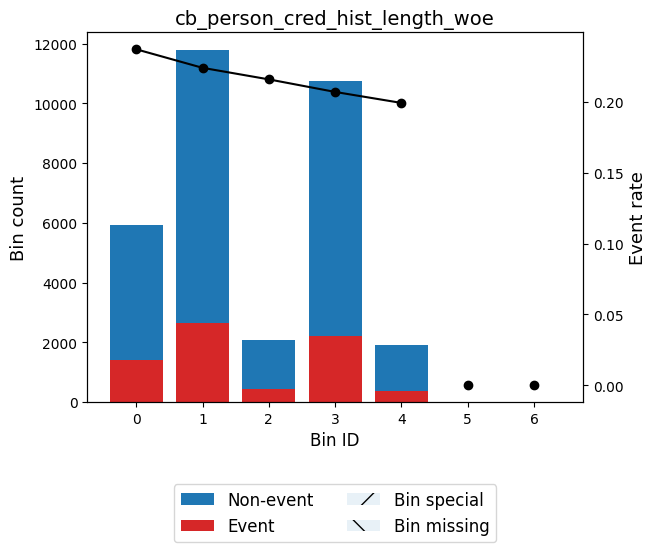


 Binning de : Unnamed: 0_woe_woe
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -0.68)   1621   0.050017        867    754    0.465145   
1       [-0.68, -0.09)   2082   0.064241       1543    539    0.258886   
2        [-0.09, 0.08)  17780   0.548613      14010   3770    0.212036   
3         [0.08, 0.34)   8662   0.267271       6977   1685    0.194528   
4          [0.34, inf)   2264   0.069857       1924    340    0.150177   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -1.133584  0.081773  0.009707  
1      -0.221463  0.003346  0.000417  
2       0.039465  0.000845  0.000106  
3       0.147623  0.005583  0.000697  
4       0.459985  0.012887  0.001597  
5            0.0  0.000000  0.000000  
6            0.0  0.000000

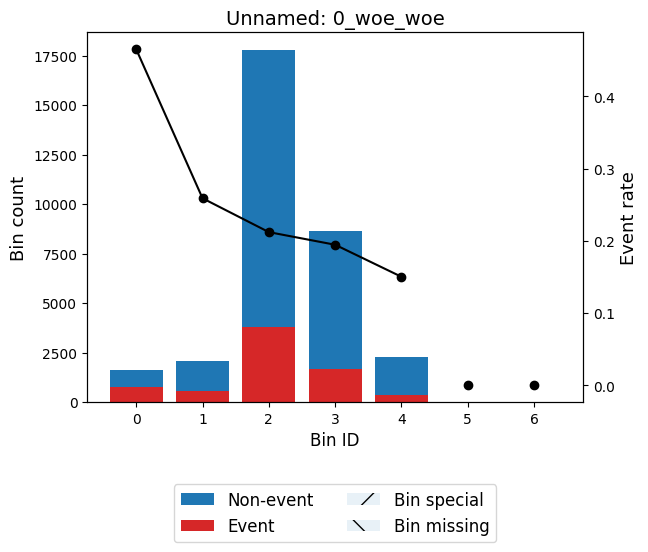


 Binning de : person_age_woe_woe
                  Bin  Count  Count (%)  Non-event  Event  Event rate  \
0       (-inf, -0.11)   4833   0.149125       3580   1253    0.259259   
1       [-0.11, 0.01)  10410   0.321207       8137   2273    0.218348   
2        [0.01, 0.06)   8494   0.262088       6681   1813    0.213445   
3        [0.06, 0.10)   3699   0.114135       2947    752    0.203298   
4         [0.10, inf)   4973   0.153445       3976    997    0.200483   
5             Special      0   0.000000          0      0    0.000000   
6             Missing      0   0.000000          0      0    0.000000   
Totals                 32409   1.000000      25321   7088    0.218705   

             WoE        IV            JS  
0      -0.223409  0.007907  9.863387e-04  
1        0.00209  0.000001  1.753033e-07  
2       0.031054  0.000251  3.131546e-05  
3       0.092576  0.000953  1.190424e-04  
4        0.11005  0.001801  2.249873e-04  
5            0.0  0.000000  0.000000e+00  
6      

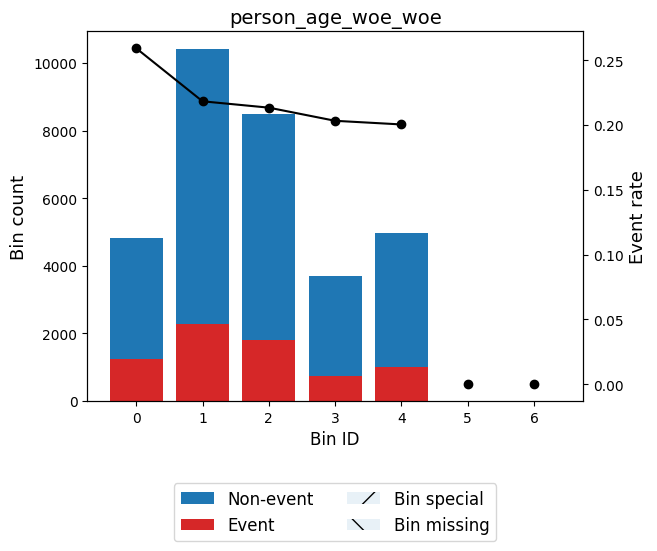


 Binning de : person_income_woe_woe
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -1.32)   1621   0.050017        593   1028    0.634176   
1       [-1.32, -0.53)   4563   0.140794       2802   1761    0.385930   
2        [-0.53, 0.26)  11397   0.351662       8863   2534    0.222339   
3         [0.26, 0.67)   6772   0.208954       5739   1033    0.152540   
4          [0.67, inf)   8056   0.248573       7324    732    0.090864   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -1.823407  0.221753  0.024422  
1      -0.808779  0.111441  0.013562  
2      -0.021145  0.000158  0.000020  
3       0.441587  0.035729  0.004430  
4       1.029901  0.191534  0.022937  
5            0.0  0.000000  0.000000  
6            0.0  0.000

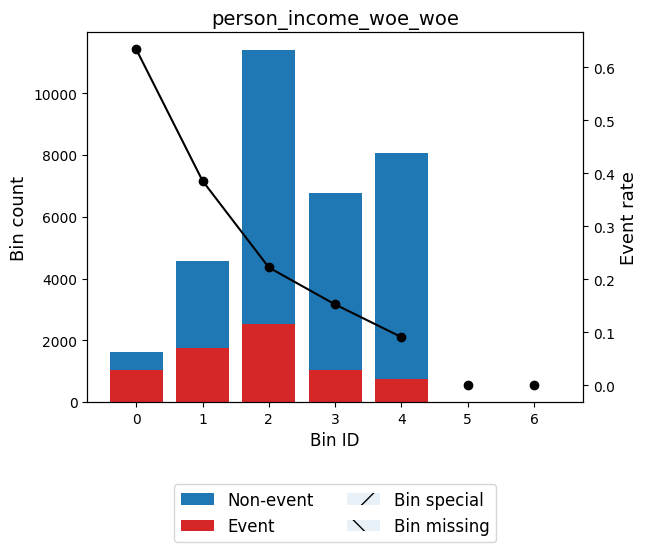


 Binning de : person_emp_length_woe_woe
                  Bin  Count  Count (%)  Non-event  Event  Event rate  \
0       (-inf, -0.10)  11701   0.361042       8487   3214    0.274677   
1       [-0.10, 0.13)   6303   0.194483       5000   1303    0.206727   
2        [0.13, 0.24)   7763   0.239532       6306   1457    0.187685   
3        [0.24, 0.35)   4462   0.137678       3686    776    0.173913   
4         [0.35, inf)   2180   0.067265       1842    338    0.155046   
5             Special      0   0.000000          0      0    0.000000   
6             Missing      0   0.000000          0      0    0.000000   
Totals                 32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -0.302212  0.035741  0.004451  
1       0.071538  0.000975  0.000122  
2       0.191891  0.008344  0.001041  
3       0.284914  0.010283  0.001281  
4        0.42233  0.010583  0.001313  
5            0.0  0.000000  0.000000  
6            0.0  0.000000  

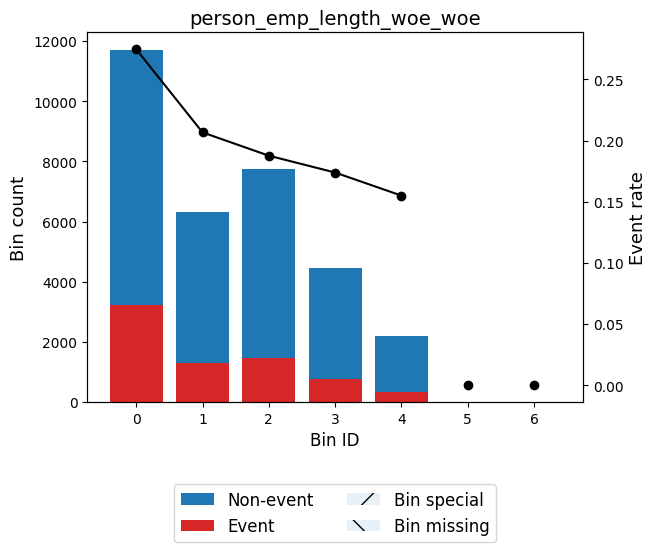


 Binning de : loan_amnt_woe_woe
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -0.42)   3415   0.105372       2232   1183    0.346413   
1       [-0.42, -0.15)   3131   0.096609       2276    855    0.273076   
2        [-0.15, 0.06)   8463   0.261131       6618   1845    0.218008   
3         [0.06, 0.28)  12378   0.381931       9961   2417    0.195266   
4          [0.28, inf)   5022   0.154957       4234    788    0.156910   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV            JS  
0      -0.638386  0.050275  6.179820e-03  
1      -0.294158  0.009043  1.126263e-03  
2       0.004083  0.000004  5.435501e-07  
3       0.142919  0.007488  9.351485e-04  
4       0.408173  0.022874  2.839528e-03  
5            0.0  0.000000  0.000000e+00  

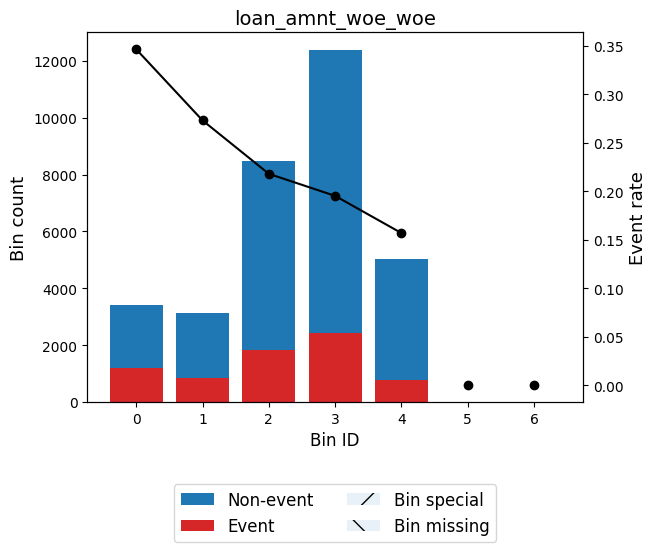


 Binning de : loan_int_rate_woe_woe
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -1.42)   2996   0.092443       1172   1824    0.608812   
1       [-1.42, -0.73)   1750   0.053997        942    808    0.461714   
2        [-0.73, 0.22)   9454   0.291709       7369   2085    0.220542   
3         [0.22, 0.76)  11072   0.341633       9336   1736    0.156792   
4          [0.76, inf)   7137   0.220217       6502    635    0.088973   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -1.715551  0.362068  0.040415  
1      -1.119788  0.085992  0.010220  
2      -0.010718  0.000034  0.000004  
3       0.409063  0.050636  0.006286  
4       1.053009  0.176058  0.021044  
5            0.0  0.000000  0.000000  
6            0.0  0.000

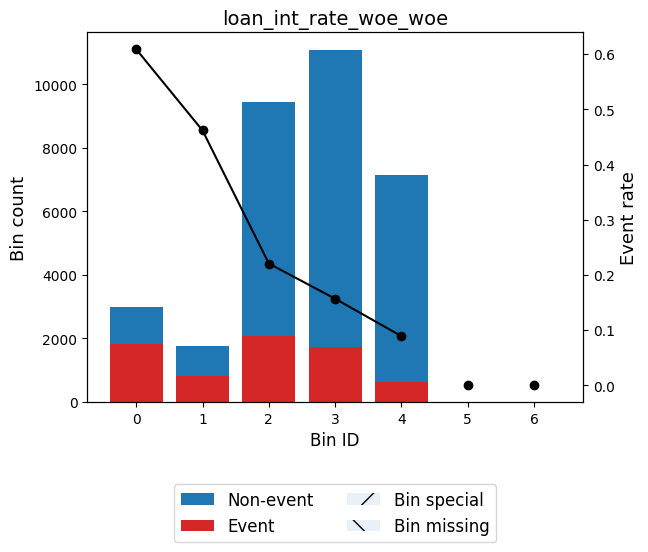


 Binning de : loan_status_woe_woe
                Bin  Count  Count (%)  Non-event  Event  Event rate  WoE   IV  \
0       (-inf, inf)  32409        1.0      25321   7088    0.218705  0.0  0.0   
1           Special      0        0.0          0      0    0.000000  0.0  0.0   
2           Missing      0        0.0          0      0    0.000000  0.0  0.0   
Totals               32409        1.0      25321   7088    0.218705       0.0   

         JS  
0       0.0  
1       0.0  
2       0.0  
Totals  0.0  


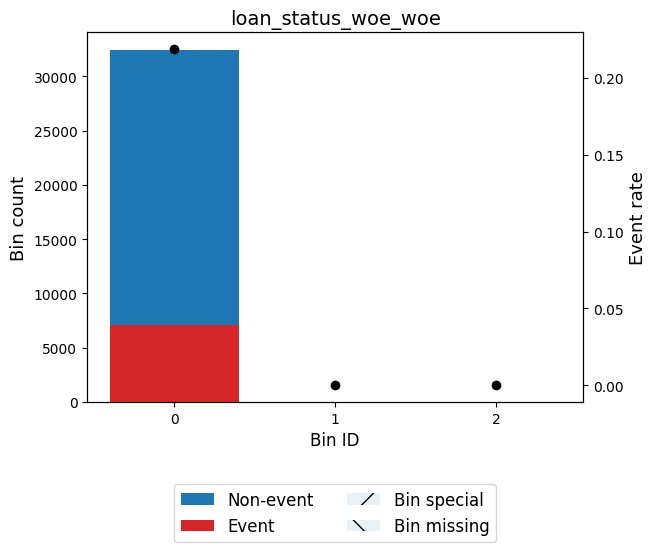


 Binning de : loan_percent_income_woe_woe
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -1.13)   3818   0.117807       1129   2689    0.704295   
1       [-1.13, -0.04)   2430   0.074979       1804    626    0.257613   
2        [-0.04, 0.43)   9075   0.280015       7383   1692    0.186446   
3         [0.43, 0.71)  10986   0.338980       9562   1424    0.129620   
4          [0.71, inf)   6100   0.188219       5443    657    0.107705   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -2.141068  0.716800  0.075646  
1       -0.21482  0.003668  0.000458  
2       0.200038  0.010575  0.001320  
3       0.631096  0.111533  0.013715  
4       0.841171  0.102848  0.012490  
5            0.0  0.000000  0.000000  
6            0.0 

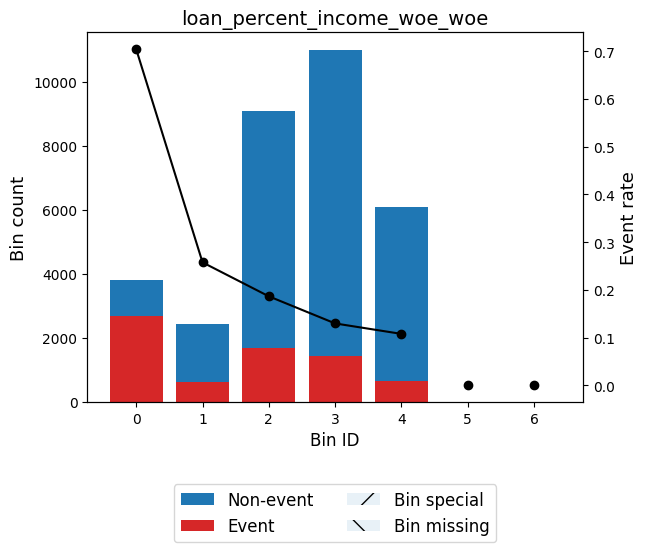


 Binning de : cb_person_cred_hist_length_woe_woe
                   Bin  Count  Count (%)  Non-event  Event  Event rate  \
0        (-inf, -0.07)   5924   0.182789       4520   1404    0.237002   
1       [-0.07, -0.01)  11781   0.363510       9143   2638    0.223920   
2        [-0.01, 0.04)   2067   0.063779       1621    446    0.215772   
3         [0.04, 0.09)  10739   0.331359       8517   2222    0.206909   
4          [0.09, inf)   1898   0.058564       1520    378    0.199157   
5              Special      0   0.000000          0      0    0.000000   
6              Missing      0   0.000000          0      0    0.000000   
Totals                  32409   1.000000      25321   7088    0.218705   

             WoE        IV        JS  
0      -0.104044  0.002036  0.000254  
1      -0.030263  0.000336  0.000042  
2       0.017249  0.000019  0.000002  
3       0.070426  0.001611  0.000201  
4       0.118341  0.000793  0.000099  
5            0.0  0.000000  0.000000  
6         

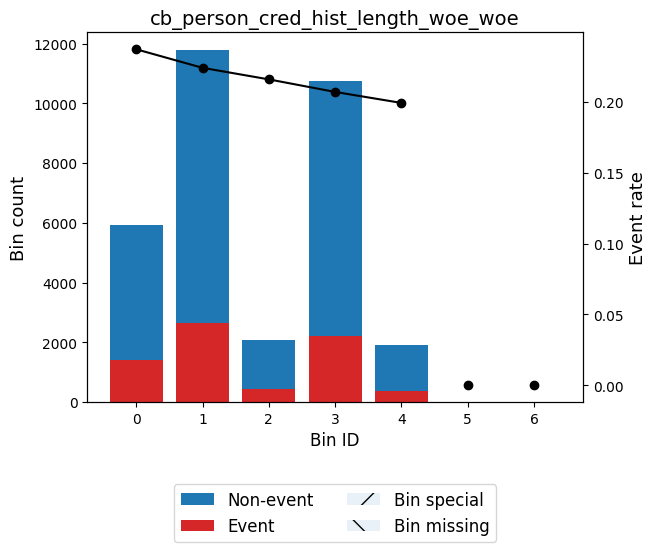

In [19]:
colonnes_num = df.select_dtypes(include=['float64', 'int64']).columns
optimal_loop(df, colonnes_num)
